In [ ]:
# ============================================================
# CELLULE 1 — Vérification du fichier
# ============================================================
import os

FICHIER = 'classification_spiral3.csv'

print("📂 Contenu de /content :")
for f in sorted(os.listdir('/content')):
    print("   -", f)

print("\n🔎 Vérification :")
if os.path.exists(f'/content/{FICHIER}'):
    taille_ko = os.path.getsize(f'/content/{FICHIER}') / 1024
    print(f"   ✅ {FICHIER}  ({taille_ko:.1f} Ko)")
    print("\n🎉 Fichier prêt. Tu peux passer à la cellule 2.")
else:
    print(f"   ❌ {FICHIER}  MANQUANT")
    print("   → Upload-le via le bouton 📁 Fichiers → ⬆️ Upload")

📂 Contenu de /content :
   - .config
   - classification_spiral3.csv
   - sample_data

🔎 Vérification :
   ✅ classification_spiral3.csv  (13.8 Ko)

🎉 Fichier prêt. Tu peux passer à la cellule 2.


In [ ]:
# ============================================================
# CELLULE 2 — Imports + métriques de classification
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, os, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


def confusion_matrix_manual(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def precision_recall_f1_macro(y_true, y_pred, n_classes):
    cm = confusion_matrix_manual(y_true, y_pred, n_classes)
    precisions, recalls, f1s = [], [], []
    for c in range(n_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        precisions.append(p); recalls.append(r); f1s.append(f)
    return (np.mean(precisions), np.mean(recalls), np.mean(f1s),
            np.array(f1s))


def cross_entropy(y_true, probs):
    n = len(y_true)
    eps = 1e-12
    return -np.mean(np.log(probs[np.arange(n), y_true] + eps))

print("✅ Cellule 2 chargée")

✅ Cellule 2 chargée


In [ ]:
# ============================================================
# CELLULE 3 — Chargement et standardisation
# ============================================================
def load_classification_data(path, label_col='label', split_col='split'):
    df = pd.read_csv(path)
    feat_cols = [c for c in df.columns if c not in (label_col, split_col)]

    tr = df[df[split_col] == 'train']
    va = df[df[split_col] == 'val']
    te = df[df[split_col] == 'test']

    Xtr = tr[feat_cols].values.astype(np.float64)
    Xva = va[feat_cols].values.astype(np.float64)
    Xte = te[feat_cols].values.astype(np.float64)
    ytr = tr[label_col].values.astype(np.int64)
    yva = va[label_col].values.astype(np.int64)
    yte = te[label_col].values.astype(np.int64)

    # Standardisation (stats du train uniquement)
    mu = Xtr.mean(axis=0); sd = Xtr.std(axis=0); sd[sd == 0] = 1.0
    Xtr = (Xtr - mu) / sd
    Xva = (Xva - mu) / sd
    Xte = (Xte - mu) / sd

    n_classes = int(max(ytr.max(), yva.max(), yte.max())) + 1

    return dict(
        Xtr=Xtr, Xva=Xva, Xte=Xte,
        ytr=ytr, yva=yva, yte=yte,
        n_classes=n_classes, d=Xtr.shape[1],
        n_tr=len(ytr), n_va=len(yva), n_te=len(yte),
        feat_cols=feat_cols, mu=mu, sd=sd
    )

print("✅ Cellule 3 chargée")

✅ Cellule 3 chargée


In [ ]:
# ============================================================
# CELLULE 4 — MLP 3 couches
# ============================================================
class MLP:
    """
    Architecture : d_in -> h1 -> h2 -> n_classes
    Activation cachée : tanh
    Sortie : softmax
    Perte : entropie croisée + L2
    """
    def __init__(self, d_in, h1, h2, n_classes, lam=1e-4, seed=42):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, np.sqrt(1.0 / d_in), (d_in, h1))
        self.b1 = np.zeros(h1)
        self.W2 = rng.normal(0, np.sqrt(1.0 / h1), (h1, h2))
        self.b2 = np.zeros(h2)
        self.W3 = rng.normal(0, np.sqrt(1.0 / h2), (h2, n_classes))
        self.b3 = np.zeros(n_classes)
        self.lam = lam
        self.shapes = [self.W1.shape, self.b1.shape,
                       self.W2.shape, self.b2.shape,
                       self.W3.shape, self.b3.shape]
        self.dim = sum(int(np.prod(s)) for s in self.shapes)
        self.X_train = None
        self.y_train = None

    def get_params(self):
        return np.concatenate([self.W1.ravel(), self.b1.ravel(),
                               self.W2.ravel(), self.b2.ravel(),
                               self.W3.ravel(), self.b3.ravel()])

    def set_params(self, theta):
        i = 0
        for name, shape in zip(['W1','b1','W2','b2','W3','b3'], self.shapes):
            n = int(np.prod(shape))
            setattr(self, name, theta[i:i+n].reshape(shape))
            i += n

    def forward(self, X):
        Z1 = X @ self.W1 + self.b1
        H1 = np.tanh(Z1)
        Z2 = H1 @ self.W2 + self.b2
        H2 = np.tanh(Z2)
        Z3 = H2 @ self.W3 + self.b3
        Z3s = Z3 - Z3.max(axis=1, keepdims=True)
        E = np.exp(Z3s)
        P = E / E.sum(axis=1, keepdims=True)
        return H1, H2, P

    def predict_proba(self, X):
        _, _, P = self.forward(X)
        return P

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def loss_and_grad(self, X, y, idx=None):
        if idx is not None:
            X = X[idx]; y = y[idx]
        n = len(y)
        H1, H2, P = self.forward(X)

        eps = 1e-12
        ce = -np.mean(np.log(P[np.arange(n), y] + eps))
        reg = 0.5 * self.lam * (
            np.sum(self.W1**2) + np.sum(self.W2**2) + np.sum(self.W3**2))
        loss = ce + reg

        Y = np.zeros_like(P); Y[np.arange(n), y] = 1.0
        D3 = (P - Y) / n
        D2 = (D3 @ self.W3.T) * (1 - H2**2)
        D1 = (D2 @ self.W2.T) * (1 - H1**2)

        dW3 = H2.T @ D3 + self.lam * self.W3
        db3 = D3.sum(axis=0)
        dW2 = H1.T @ D2 + self.lam * self.W2
        db2 = D2.sum(axis=0)
        dW1 = X.T @ D1 + self.lam * self.W1
        db1 = D1.sum(axis=0)

        g = np.concatenate([dW1.ravel(), db1.ravel(),
                            dW2.ravel(), db2.ravel(),
                            dW3.ravel(), db3.ravel()])
        return loss, g

    def loss(self, X, y):
        return self.loss_and_grad(X, y)[0]

print("✅ Cellule 4 chargée")

✅ Cellule 4 chargée


In [ ]:
# ============================================================
# CELLULE 5 — Optimiseurs
# ============================================================
METHODS = ['gd', 'gd_ls', 'sgd', 'momentum',
           'adagrad', 'rmsprop', 'adam']

COLORS = {
    'gd':       'tab:blue',
    'gd_ls':    'tab:orange',
    'sgd':      'tab:green',
    'momentum': 'tab:red',
    'adagrad':  'tab:purple',
    'rmsprop':  'tab:brown',
    'adam':     'tab:pink',
}


def armijo_line_search(model, theta, g, X, y, eta0, c=1e-4, max_iter=20):
    """Recherche bornée approchée (backtracking Armijo)."""
    d = -g
    t = eta0
    loss0 = model.loss(X, y)
    gd = g @ d
    for _ in range(max_iter):
        model.set_params(theta + t * d)
        loss_new = model.loss(X, y)
        if loss_new < loss0 + c * t * gd:
            return t, loss_new
        t *= 0.5
    model.set_params(theta)
    return t, loss0


def optimize(model, method, eta, n_epochs, batch_size=32,
             mu=0.9, rho=0.9, beta1=0.9, beta2=0.999, eps=1e-8,
             seed=42):
    rng = np.random.default_rng(seed)
    theta = model.get_params()
    v = np.zeros_like(theta); s = np.zeros_like(theta); m = np.zeros_like(theta)
    n_grad = n_loss = n_updates = 0
    loss_hist = []
    X, y = model.X_train, model.y_train
    n = len(y)
    t = 0

    for ep in range(n_epochs):
        if method in ('gd', 'gd_ls'):
            loss, g = model.loss_and_grad(X, y); n_grad += 1
            if method == 'gd':
                theta = theta - eta * g
            else:
                eta_t, _ = armijo_line_search(model, theta, g, X, y, eta)
                theta = theta - eta_t * g
            n_updates += 1; t += 1
        else:
            idx = rng.permutation(n)
            for b in range(0, n, batch_size):
                bidx = idx[b:b + batch_size]
                _, g = model.loss_and_grad(X, y, bidx); n_grad += 1
                if method == 'sgd':
                    theta = theta - eta * g
                elif method == 'momentum':
                    v = mu * v + g
                    theta = theta - eta * v
                elif method == 'adagrad':
                    s = s + g**2
                    theta = theta - eta * g / (np.sqrt(s) + eps)
                elif method == 'rmsprop':
                    s = rho * s + (1 - rho) * g**2
                    theta = theta - eta * g / (np.sqrt(s) + eps)
                elif method == 'adam':
                    m = beta1 * m + (1 - beta1) * g
                    s = beta2 * s + (1 - beta2) * g**2
                    mh = m / (1 - beta1**(t + 1))
                    sh = s / (1 - beta2**(t + 1))
                    theta = theta - eta * mh / (np.sqrt(sh) + eps)
                n_updates += 1; t += 1
        model.set_params(theta)
        loss_hist.append(model.loss(X, y)); n_loss += 1

    return theta, np.array(loss_hist), n_grad, n_loss, n_updates

print("✅ Cellule 5 chargée")

✅ Cellule 5 chargée


In [ ]:
# ============================================================
# CELLULE 6 — Vérification du gradient
# ============================================================
def check_gradient_mlp(model, X, y, seed=42, n_check=5, h=1e-5):
    rng = np.random.default_rng(seed)
    theta = rng.normal(0, 0.1, model.dim)
    model.set_params(theta)
    _, g = model.loss_and_grad(X, y)
    idxs = rng.choice(model.dim, size=min(n_check, model.dim), replace=False)
    errs = []
    for i in idxs:
        tp = theta.copy(); tp[i] += h
        tm = theta.copy(); tm[i] -= h
        model.set_params(tp); lp = model.loss(X, y)
        model.set_params(tm); lm = model.loss(X, y)
        num = (lp - lm) / (2 * h)
        den = max(abs(num), abs(g[i]), 1e-12)
        errs.append(abs(num - g[i]) / den)
    return errs

print("✅ Cellule 6 chargée")

✅ Cellule 6 chargée


In [ ]:
# ============================================================
# CELLULE 7 — Entraînement + sélection de η
# ============================================================
def train_one(model, method, eta, n_epochs, batch_size, seed,
              X_val, y_val):
    t0 = time.time()
    theta, loss_hist, n_grad, n_loss, n_up = optimize(
        model, method, eta, n_epochs, batch_size, seed=seed)
    elapsed = time.time() - t0
    model.set_params(theta)

    val_acc = accuracy(y_val, model.predict(X_val))
    val_loss = model.loss(X_val, y_val)

    return dict(theta=theta, loss_hist=loss_hist,
                val_acc=val_acc, val_loss=val_loss,
                best_ep=int(np.argmin(loss_hist)),
                time=elapsed, n_grad=n_grad,
                n_loss=n_loss, n_updates=n_up)


def search_and_eval_mlp(data, archi, method, eta_grid, n_epochs,
                         batch_size, seeds=(42, 123, 2024)):
    Xtr, ytr = data['Xtr'], data['ytr']
    Xva, yva = data['Xva'], data['yva']
    Xte, yte = data['Xte'], data['yte']
    C = data['n_classes']

    scan = []
    for eta in eta_grid:
        accs = []
        for seed in seeds:
            m = MLP(archi[0], archi[1], archi[2], C, lam=1e-4, seed=seed)
            m.X_train, m.y_train = Xtr, ytr
            r = train_one(m, method, eta, n_epochs, batch_size, seed,
                          Xva, yva)
            accs.append(r['val_acc'])
        scan.append((eta, np.mean(accs)))
    best_eta = max(scan, key=lambda x: x[1])[0]

    metrics = {k: [] for k in ['acc_t', 'prec_t', 'rec_t', 'f1_t',
                                'ce_t', 'val_acc', 'val_loss',
                                'time', 'n_grad', 'n_loss', 'n_up',
                                'best_ep']}
    f1_per_class_all = []
    preds_all, probs_all = [], []
    for seed in seeds:
        m = MLP(archi[0], archi[1], archi[2], C, lam=1e-4, seed=seed)
        m.X_train, m.y_train = Xtr, ytr
        r = train_one(m, method, best_eta, n_epochs, batch_size, seed,
                      Xva, yva)
        m.set_params(r['theta'])
        probs = m.predict_proba(Xte)
        preds = np.argmax(probs, axis=1)
        p, rec, f1, f1s = precision_recall_f1_macro(yte, preds, C)
        metrics['acc_t'].append(accuracy(yte, preds))
        metrics['prec_t'].append(p)
        metrics['rec_t'].append(rec)
        metrics['f1_t'].append(f1)
        metrics['ce_t'].append(cross_entropy(yte, probs))
        metrics['val_acc'].append(r['val_acc'])
        metrics['val_loss'].append(r['val_loss'])
        metrics['time'].append(r['time'])
        metrics['n_grad'].append(r['n_grad'])
        metrics['n_loss'].append(r['n_loss'])
        metrics['n_up'].append(r['n_updates'])
        metrics['best_ep'].append(r['best_ep'])
        f1_per_class_all.append(f1s)
        preds_all.append(preds)
        probs_all.append(probs)

    return dict(best_eta=best_eta, metrics=metrics, scan=scan,
                f1_per_class=np.mean(f1_per_class_all, axis=0),
                preds=preds_all, probs=probs_all)

print("✅ Cellule 7 chargée")

✅ Cellule 7 chargée


In [ ]:
# ============================================================
# CELLULE 8 — Figures
# ============================================================
def plot_classification_results(name, data, results, outdir='figs'):
    plt.close('all')
    os.makedirs(outdir, exist_ok=True)
    yte = data['yte']
    C = data['n_classes']

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # (a) Scan de η
    for method in METHODS:
        if method in results:
            sc = results[method]['scan']
            etas = [s[0] for s in sc]; accs = [s[1] for s in sc]
            axes[0, 0].plot(etas, accs, 'o-', label=method,
                            color=COLORS[method])
    axes[0, 0].set_xscale('log')
    axes[0, 0].set_xlabel('η')
    axes[0, 0].set_ylabel('Exactitude validation')
    axes[0, 0].set_title(f'{name} — sélection de η (validation)')
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].grid(True, alpha=0.3)

    # (b) Exactitude test par méthode
    methods_ok = [m for m in METHODS if m in results]
    accs = [np.mean(results[m]['metrics']['acc_t']) for m in methods_ok]
    axes[0, 1].bar(range(len(methods_ok)), accs,
                   color=[COLORS[m] for m in methods_ok])
    axes[0, 1].set_xticks(range(len(methods_ok)))
    axes[0, 1].set_xticklabels(methods_ok, rotation=45)
    axes[0, 1].set_ylabel('Exactitude test')
    axes[0, 1].set_title(f'{name} — exactitude test par méthode')
    axes[0, 1].grid(True, alpha=0.3, axis='y')

    # (c) Matrice de confusion
    best = max(methods_ok,
               key=lambda m: np.mean(results[m]['metrics']['acc_t']))
    preds = results[best]['preds'][0]
    cm = confusion_matrix_manual(yte, preds, C)
    im = axes[1, 0].imshow(cm, cmap='Blues')
    axes[1, 0].set_xlabel('Prédit'); axes[1, 0].set_ylabel('Réel')
    axes[1, 0].set_title(f'Matrice de confusion (meilleure : {best})')
    for i in range(C):
        for j in range(C):
            axes[1, 0].text(j, i, str(cm[i, j]),
                            ha='center', va='center',
                            color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.colorbar(im, ax=axes[1, 0])

    # (d) F1 par classe
    f1s = results[best]['f1_per_class']
    axes[1, 1].bar(range(C), f1s, color='steelblue')
    axes[1, 1].set_xticks(range(C))
    axes[1, 1].set_xlabel('Classe'); axes[1, 1].set_ylabel('F1')
    axes[1, 1].set_title(f'F1 par classe (meilleure : {best})')
    axes[1, 1].set_ylim(0, 1.05)
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    fig.suptitle(f'{name} — Exercice 2 : classification', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{outdir}/{name}_exo2.png', dpi=130, bbox_inches='tight')
    plt.show()
    plt.close()


def plot_decision_boundary_2d(data, results, outdir='figs'):
    """Frontière de décision RÉELLE (zones + points)."""
    plt.close('all')
    os.makedirs(outdir, exist_ok=True)
    Xtr, ytr = data['Xtr'], data['ytr']
    Xte, yte = data['Xte'], data['yte']
    C = data['n_classes']

    best = max(results,
               key=lambda m: np.mean(results[m]['metrics']['acc_t']))

    # Reconstruction du modèle
    m = MLP(data['d'], 32, 16, C, lam=1e-4, seed=42)
    m.X_train, m.y_train = Xtr, ytr

    # Réentraînement avec le η optimal
    theta, _, _, _, _ = optimize(
        m, best, results[best]['best_eta'],
        n_epochs=100, batch_size=32, seed=42)
    m.set_params(theta)

    # Grille 2D
    pad = 0.5
    xx, yy = np.meshgrid(
        np.linspace(Xte[:, 0].min() - pad, Xte[:, 0].max() + pad, 300),
        np.linspace(Xte[:, 1].min() - pad, Xte[:, 1].max() + pad, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = m.predict(grid).reshape(xx.shape)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # (a) Train + frontière
    axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='viridis',
                     levels=np.arange(-0.5, C))
    axes[0].scatter(Xtr[:, 0], Xtr[:, 1], c=ytr, s=15,
                    cmap='viridis', edgecolor='k', linewidth=0.3)
    axes[0].set_title('Train (y réel + frontière)')

    # (b) Test + frontière
    axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='viridis',
                     levels=np.arange(-0.5, C))
    axes[1].scatter(Xte[:, 0], Xte[:, 1], c=yte, s=15,
                    cmap='viridis', edgecolor='k', linewidth=0.3)
    axes[1].set_title('Test (y réel + frontière)')

    # (c) Test prédit
    axes[2].contourf(xx, yy, Z, alpha=0.3, cmap='viridis',
                     levels=np.arange(-0.5, C))
    axes[2].scatter(Xte[:, 0], Xte[:, 1],
                    c=results[best]['preds'][0], s=15,
                    cmap='viridis', edgecolor='k', linewidth=0.3)
    axes[2].set_title(f'Test (prédit, {best})')

    for ax in axes:
        ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

    fig.suptitle('Spirales — frontière de décision apprise '
                 f'({best}, moyenne 3 graines)', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{outdir}/spiral3_decision.png', dpi=130,
                bbox_inches='tight')
    plt.show()
    plt.close()


def plot_confusion_matrix_full(data, results, outdir='figs'):
    plt.close('all')
    os.makedirs(outdir, exist_ok=True)
    yte = data['yte']
    C = data['n_classes']
    methods_ok = [m for m in METHODS if m in results]

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for i, method in enumerate(methods_ok):
        preds = results[method]['preds'][0]
        cm = confusion_matrix_manual(yte, preds, C)
        im = axes[i].imshow(cm, cmap='Blues')
        axes[i].set_title(method)
        axes[i].set_xlabel('Prédit'); axes[i].set_ylabel('Réel')
        for r in range(C):
            for c in range(C):
                axes[i].text(c, r, str(cm[r, c]),
                             ha='center', va='center',
                             color='white' if cm[r, c] > cm.max()/2 else 'black')
    axes[-1].axis('off')
    fig.suptitle('Spirales — matrices de confusion (toutes méthodes)',
                 fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{outdir}/spiral3_confusions.png', dpi=130, bbox_inches='tight')
    plt.show()
    plt.close()

print("✅ Cellule 8 chargée")

✅ Cellule 8 chargée


In [ ]:
# ============================================================
# CELLULE 9 — run_experiment
# ============================================================
def run_experiment_classification(csv_path, name,
                                   hidden=(32, 16),
                                   n_epochs=100,
                                   batch_size=32,
                                   eta_grid=(1e-3, 1e-2, 5e-2, 1e-1, 5e-1),
                                   seeds=(42, 123, 2024)):

    print(f"\n===== {name} =====")
    data = load_classification_data(csv_path)
    data['name'] = name
    print(f"n_train={data['n_tr']}, n_val={data['n_va']}, "
          f"n_test={data['n_te']}, d={data['d']}, "
          f"C={data['n_classes']}")

    archi = (data['d'], hidden[0], hidden[1], data['n_classes'])

    # Vérification gradient
    m_check = MLP(*archi, lam=1e-4, seed=42)
    errs = check_gradient_mlp(m_check, data['Xtr'][:50], data['ytr'][:50])
    print(f"  Vérif gradient : {['%.2e' % e for e in errs]}")

    # Entraînement
    results = {}
    for method in METHODS:
        print(f"  >> {method}")
        results[method] = search_and_eval_mlp(
            data, archi, method, eta_grid,
            n_epochs, batch_size, seeds)
        print(f"     η* = {results[method]['best_eta']}, "
              f"acc_val = {np.mean(results[method]['metrics']['val_acc']):.4f}")

    # Tableau
    rows = []
    for method in METHODS:
        m = results[method]['metrics']
        rows.append(dict(
            méthode=method,
            η=results[method]['best_eta'],
            époque_best=np.mean(m['best_ep']),
            acc_val=np.mean(m['val_acc']),
            acc_test=np.mean(m['acc_t']),
            précision=np.mean(m['prec_t']),
            rappel=np.mean(m['rec_t']),
            F1=np.mean(m['f1_t']),
            CE=np.mean(m['ce_t']),
            temps_s=np.mean(m['time']),
            appels_grad=int(np.mean(m['n_grad'])),
            mises_à_jour=int(np.mean(m['n_up'])),
        ))
    df = pd.DataFrame(rows)
    print("\n" + df.to_string(index=False))
    df.to_csv(f'resultats_{name}_exo2.csv', index=False)

    # Figures
    plot_classification_results(name, data, results)
    plot_decision_boundary_2d(data, results)
    plot_confusion_matrix_full(data, results)

    return df, data, results

print("✅ Cellule 9 chargée")

✅ Cellule 9 chargée



===== spiral3 =====
n_train=270, n_val=90, n_test=90, d=2, C=3
  Vérif gradient : ['2.89e-09', '6.05e-07', '8.05e-10', '3.89e-09', '4.98e-09']
  >> gd
     η* = 0.5, acc_val = 0.9926
  >> gd_ls
     η* = 0.5, acc_val = 0.9926
  >> sgd
     η* = 0.05, acc_val = 0.9889
  >> momentum
     η* = 0.01, acc_val = 0.9889
  >> adagrad
     η* = 0.1, acc_val = 0.9852
  >> rmsprop
     η* = 0.001, acc_val = 0.9963
  >> adam
     η* = 0.001, acc_val = 0.9926

 méthode     η  époque_best  acc_val  acc_test  précision   rappel       F1       CE  temps_s  appels_grad  mises_à_jour
      gd 0.500    99.000000 0.992593  0.992593   0.992832 0.992593 0.992591 0.047833 0.407577          100           100
   gd_ls 0.500    99.000000 0.992593  0.992593   0.992832 0.992593 0.992591 0.047833 0.628245          100           100
     sgd 0.050    99.000000 0.988889  0.992593   0.992832 0.992593 0.992591 0.057990 0.426235          900           900
momentum 0.010    99.000000 0.988889  0.988889   0.989247 0.988

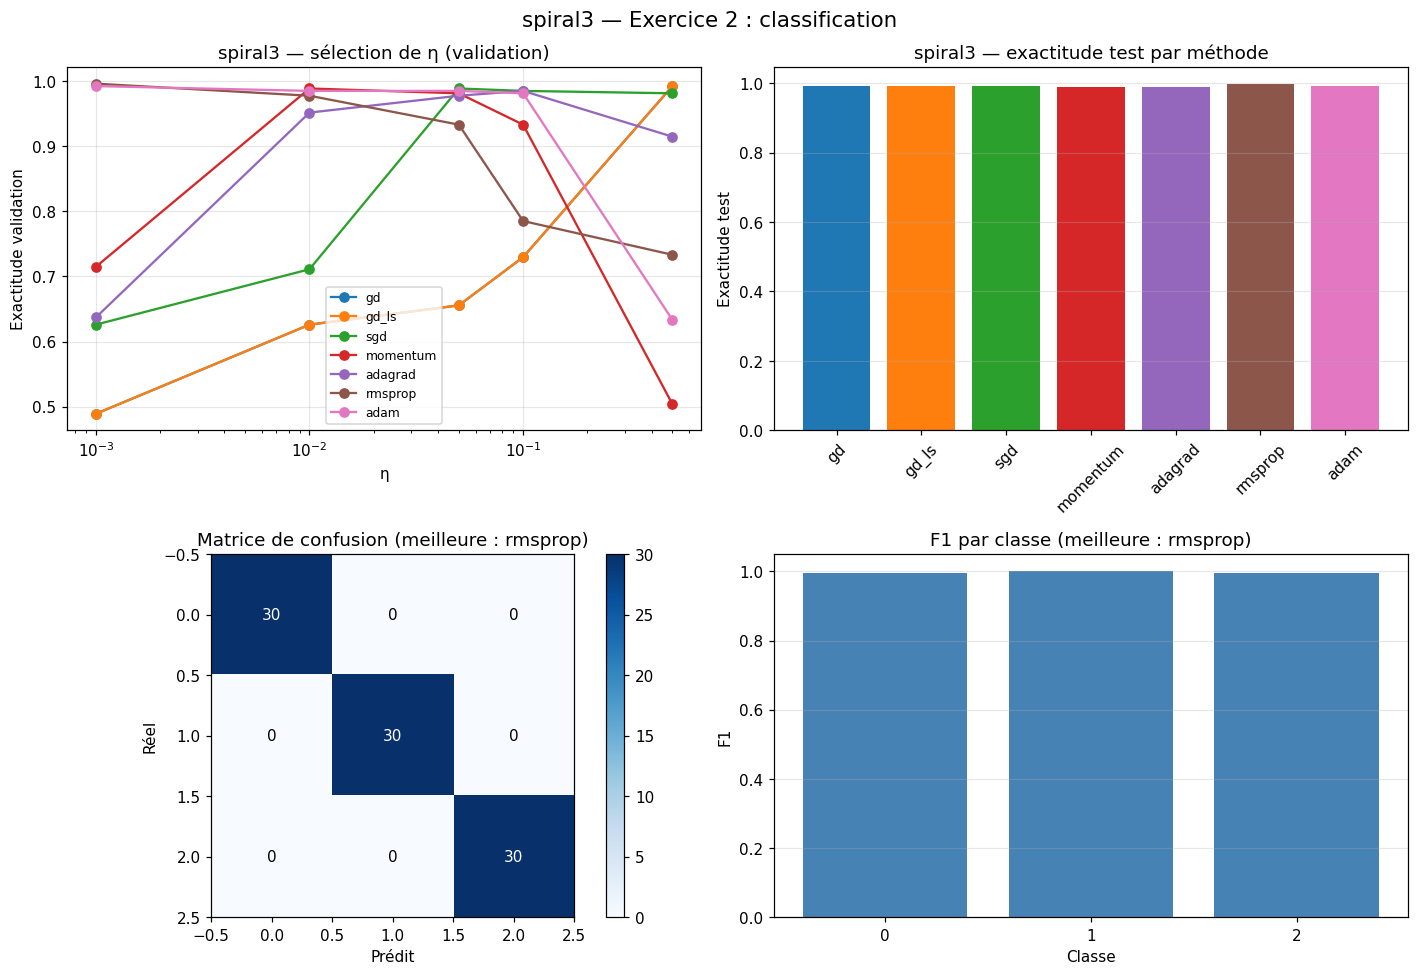

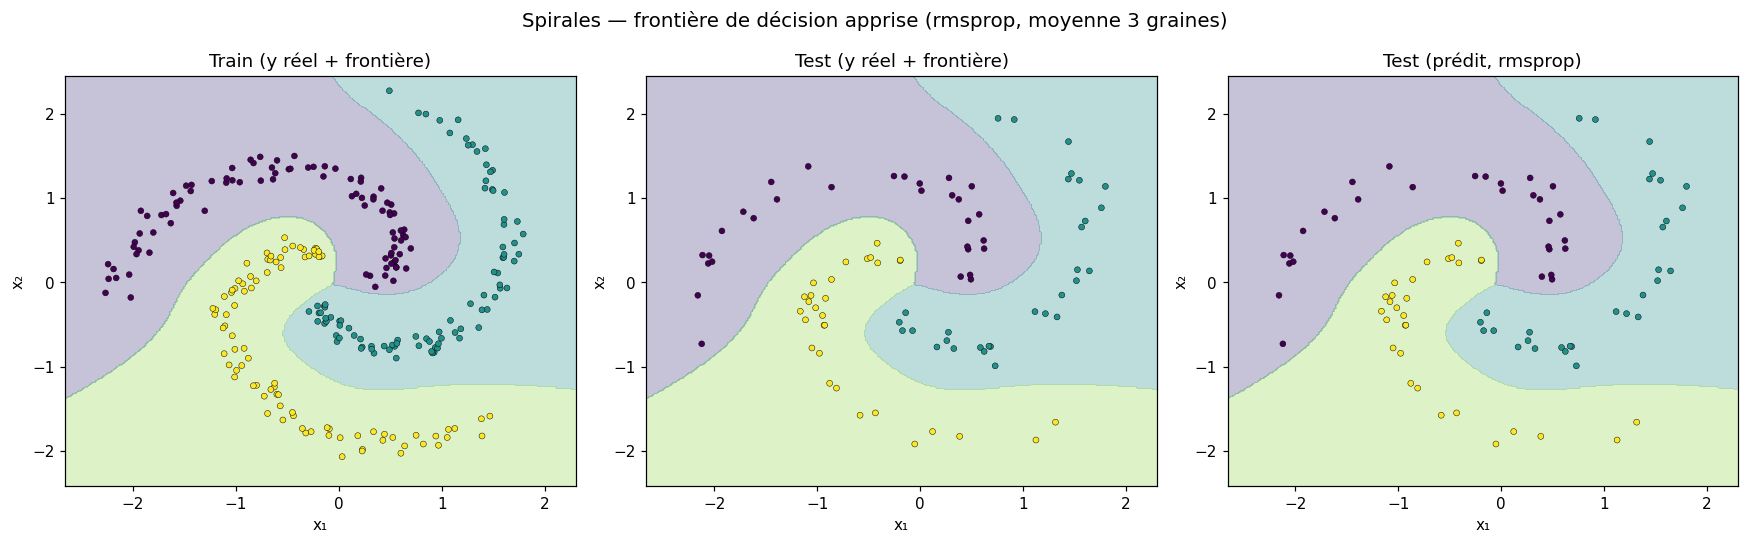

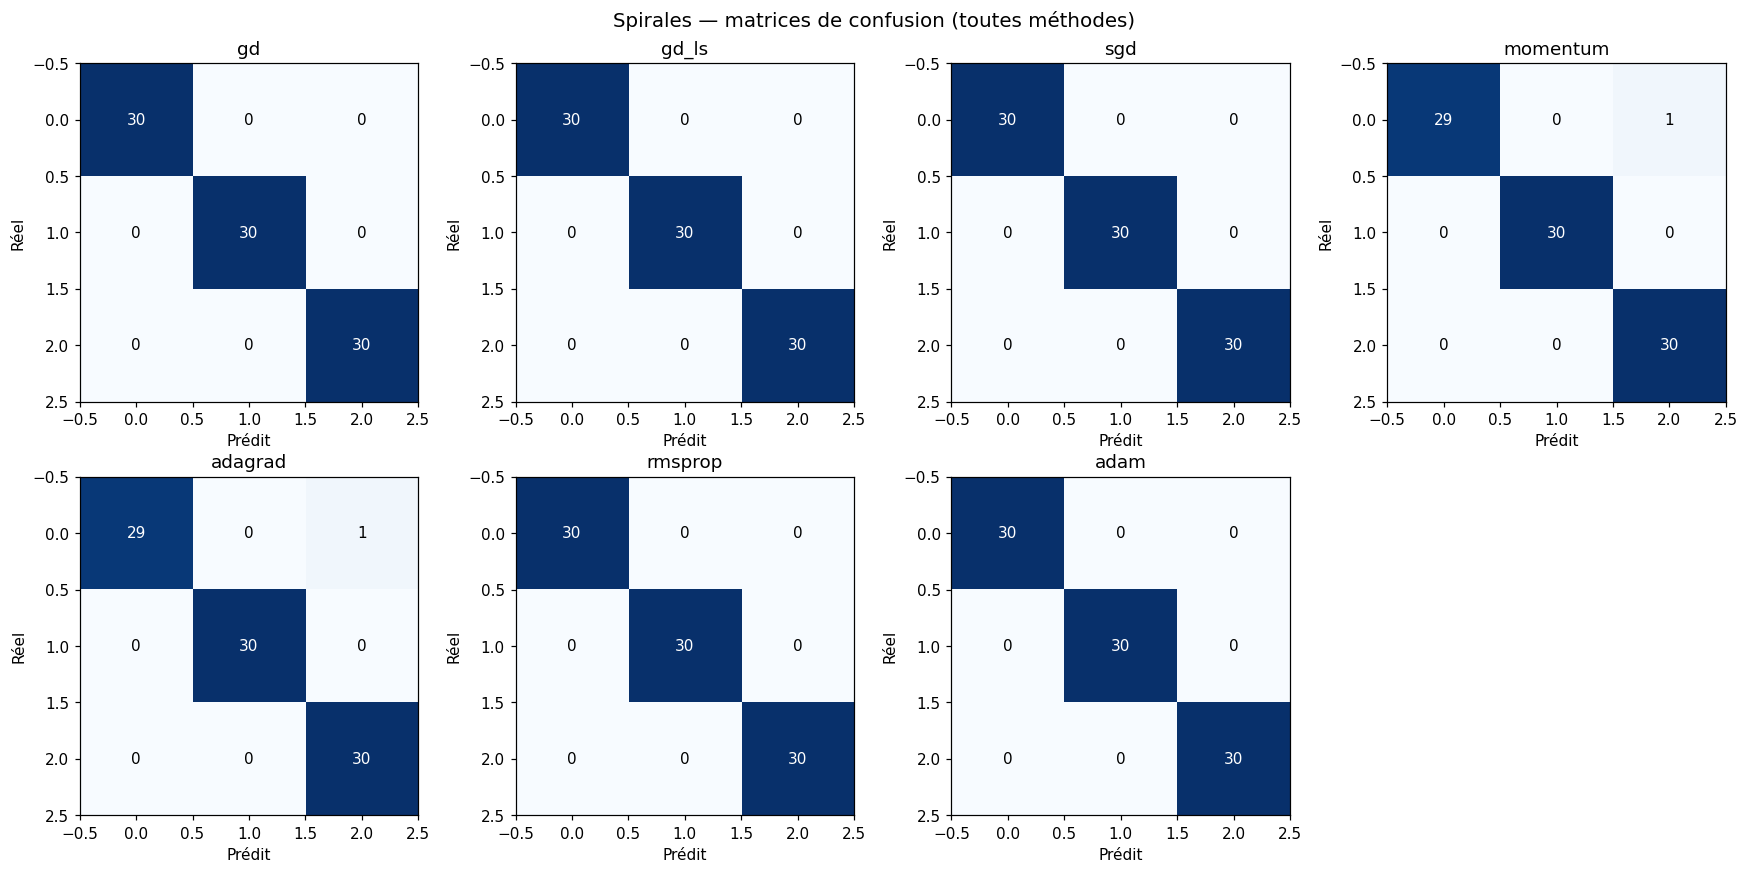

In [ ]:
# ============================================================
# CELLULE 10 bis — LANCEMENT FINAL (3 graines, 100 époques)
# ============================================================
df_spiral, data_spiral, results_spiral = run_experiment_classification(
    'classification_spiral3.csv', 'spiral3',
    hidden=(32, 16),
    n_epochs=100,
    batch_size=32,
    seeds=(42, 123, 2024)
)

In [ ]:
# ============================================================
# CELLULE 11 — Téléchargement (avec vérifications)
# ============================================================
from google.colab import files
import shutil, os

# CSV de résultats
csv_path = 'resultats_spiral3_exo2.csv'
if os.path.exists(csv_path):
    print(f"📥 Téléchargement : {csv_path}")
    files.download(csv_path)
else:
    print(f"⚠️ {csv_path} introuvable — lance d'abord la cellule 10.")

# Figures
if os.path.exists('figs') and len(os.listdir('figs')) > 0:
    print(f"\n📦 Compression de figs/ ({len(os.listdir('figs'))} fichiers)")
    shutil.make_archive('figs_exo2', 'zip', 'figs')
    files.download('figs_exo2.zip')
    print("✅ Téléchargement des figures lancé")
else:
    print("\n⚠️ Le dossier figs/ n'existe pas ou est vide.")
    print("   → Lance d'abord la cellule 10.")

📥 Téléchargement : resultats_spiral3_exo2.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📦 Compression de figs/ (3 fichiers)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Téléchargement des figures lancé
